In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
emails_df = pd.read_csv('../data/02_cleaned_emails_internal.csv')
emails_df.head()

/var/folders/cv/swyglqyx1tlc_6vc0p615fhr0000gn/T/ipykernel_13712/1303235301.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251

,Date,From,To,Subject,X_From,X_To,Message,Entire-Message,DISC_rule,DISC_manual,...,Unnamed: 1098,Unnamed: 1099,Unnamed: 1100,Unnamed: 1101,Unnamed: 1102,Unnamed: 1103,Unnamed: 1104,Unnamed: 1105,Unnamed: 1106,Unnamed: 1107
0,"Fri, 4 May 2001 13:51:00 -0700 (PDT)",phillip.allen@enron.com,john.lavorato@enron.com,Re:,Phillip K Allen,John J Lavorato <John J Lavorato/ENRON@enronXg...,Traveling to have a business meeting takes the...,Re: Traveling to have a business meeting takes...,NaN,"(C,I)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Mon, 23 Oct 2000 06:13:00 -0700 (PDT)",phillip.allen@enron.com,randall.gay@enron.com,No Subject,Phillip K Allen,Randall L Gay,"Randy,\nCan you send me a schedule of the sala...","No Subject Randy,\nCan you send me a schedule ...",NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Tue, 17 Oct 2000 02:26:00 -0700 (PDT)",phillip.allen@enron.com,mark.scott@enron.com,Re: High Speed Internet Access,Phillip K Allen,Mark Scott,1. login: pallen pw: ke9davis\nI don't think t...,Re: High Speed Internet Access 1. login: palle...,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Mon, 16 Oct 2000 06:42:00 -0700 (PDT)",phillip.allen@enron.com,buck.buckner@honeywell.com,Re: FW: fixed forward or other Collar floor ga...,Phillip K Allen,"""Buckner, Buck"" <buck.buckner@honeywell.com> @...","Mr. Buckner,\nFor delivered gas behind San Die...",Re: FW: fixed forward or other Collar floor ga...,NaN,"(S,)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Fri, 13 Oct 2000 06:45:00 -0700 (PDT)",phillip.allen@enron.com,stagecoachmama@hotmail.com,No Subject,Phillip K Allen,stagecoachmama@hotmail.com,"Lucy,\nHere are the rentrolls:\nOpen them and ...","No Subject Lucy,\nHere are the rentrolls:\nOpe...",NaN,"(S,)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
emails_df.columns

Index(['Date', 'From', 'To', 'Subject', 'X_From', 'X_To', 'Message',
       'Entire-Message', 'DISC_rule', 'DISC_manual',
       ...
       'Unnamed: 1098', 'Unnamed: 1099', 'Unnamed: 1100', 'Unnamed: 1101',
       'Unnamed: 1102', 'Unnamed: 1103', 'Unnamed: 1104', 'Unnamed: 1105',
       'Unnamed: 1106', 'Unnamed: 1107'],
      dtype='object', length=1108)

In [ ]:
emails_df = emails_df.loc[:, ~emails_df.columns.str.startswith('Unnamed')]
emails_df_msg_label = emails_df.drop(columns=['X_From', 'X_To', 'Date', 'From', 'To', 'Subject', 'Message'])
emails_df_msg_label.head()

,Entire-Message,DISC_rule,DISC_manual,DISC_fiNl,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,...,Unnamed: 1098,Unnamed: 1099,Unnamed: 1100,Unnamed: 1101,Unnamed: 1102,Unnamed: 1103,Unnamed: 1104,Unnamed: 1105,Unnamed: 1106,Unnamed: 1107
0,Re: Traveling to have a business meeting takes...,NaN,"(C,I)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"No Subject Randy,\nCan you send me a schedule ...",NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Re: High Speed Internet Access 1. login: palle...,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Re: FW: fixed forward or other Collar floor ga...,NaN,"(S,)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"No Subject Lucy,\nHere are the rentrolls:\nOpe...",NaN,"(S,)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
emails_df.info()
emails_df.describe()
# emails_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294177 entries, 0 to 294176
Columns: 1108 entries, Date to Unnamed: 1107
dtypes: object(1108)
memory usage: 2.4+ GB


,Date,From,To,Subject,X_From,X_To,Message,Entire-Message,DISC_rule,DISC_manual,...,Unnamed: 1098,Unnamed: 1099,Unnamed: 1100,Unnamed: 1101,Unnamed: 1102,Unnamed: 1103,Unnamed: 1104,Unnamed: 1105,Unnamed: 1106,Unnamed: 1107
count,292982,120856,79449,67286,65381,64900,64660,64492,103,226,...,1,1,1,1,1,1,1,1,1,1
unique,124745,27779,31235,49491,7581,29139,64535,64407,42,45,...,1,1,1,1,1,1,1,1,1,1
top,[DATE] [TIME],kay.mann@enron.com,louise.kitchen@enron.com,No Subject,Kay Mann,Tana Jones,and he intends to be a part of it. In fact,another reason stockholders might be panicky....,arranged a trip to New York to calm analysts ...,N,...,Zadorozhny,Roman </O=ENRON/OU=NA/CN=RECIPIENTS/CN=Rzadoro>,Zhang,Michelle </O=ENRON/OU=NA/CN=RECIPIENTS/CN=Mzh...,Zhang,Jian </O=ENRON/OU=NA/CN=RECIPIENTS/CN=Jzhang8>,Zhurgenbay,Dulat </O=ENRON/OU=NA/CN=RECIPIENTS/CN=Notesa...,There is currently an opening for a Analyst or...,Analyst or Associate - Middle Market There is ...
freq,23653,1615,797,2208,1545,691,10,10,10,50,...,1,1,1,1,1,1,1,1,1,1


In [6]:
emails_df_msg_label.to_csv('../data/03_cleaned_email_msg.csv', index=False)

## Use Rule-Based Keyword Matching to label sample emails

In [7]:
emails_df_rule_based_samples = emails_df_msg_label.sample(5000, random_state=32).copy()
rule_based_ids = emails_df_rule_based_samples.index.tolist()
print(rule_based_ids)

[38893, 35276, 151736, 76899, 119907, 175287, 248438, 80197, 82942, 230235, 210798, 174012, 93579, 66311, 119639, 289903, 205067, 31431, 290070, 153895, 39137, 208669, 154572, 160664, 104220, 192802, 14781, 46914, 1130, 148009, 214426, 75232, 195606, 222828, 68305, 122394, 276325, 182877, 180938, 31963, 83054, 212250, 163532, 208458, 240690, 29757, 240971, 46479, 169541, 107604, 38193, 81926, 196444, 68847, 157912, 172162, 290481, 267278, 233259, 96802, 263748, 142172, 157635, 205686, 218731, 15423, 287994, 117487, 292082, 262352, 4707, 245986, 128201, 206501, 137114, 179119, 237217, 167924, 189160, 106985, 220258, 209576, 263237, 7034, 47544, 38519, 266637, 173786, 179441, 38335, 124500, 232287, 122129, 277756, 19756, 211983, 120987, 94916, 41731, 55194, 203136, 181669, 269322, 259445, 220903, 136756, 61041, 229162, 17558, 163691, 280920, 287378, 247432, 136299, 84148, 200097, 28179, 286036, 1052, 282967, 47418, 104186, 145556, 115257, 142287, 95864, 248355, 119406, 284483, 226375, 15

In [8]:
# lowercasing and remove punctuation
PUNC_PATTERN = re.compile(r'[^\w\s]')

def preprocess_text_for_rule_based(text):
    if not isinstance(text, str):
        return ''


    text = PUNC_PATTERN.sub('', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip().lower()
    return text

emails_df_rule_based_samples['Entire-Message'] = emails_df_rule_based_samples['Entire-Message'].apply(preprocess_text_for_rule_based)
emails_df_rule_based_samples.head()

,Entire-Message,DISC_rule,DISC_manual,DISC_fiNl,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,...,Unnamed: 1098,Unnamed: 1099,Unnamed: 1100,Unnamed: 1101,Unnamed: 1102,Unnamed: 1103,Unnamed: 1104,Unnamed: 1105,Unnamed: 1106,Unnamed: 1107
38893,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35276,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151736,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76899,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119907,no subject just that if the new grp that ive c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
DISC_KEYWORDS = {
    'D' : ["deadline", "urgent", "now", "action", "priority", "resolve", "results",
        "decision", "goal", "challenge", "do it", "fast", "push", "lead", "firm", "pressure", "action required",
        "quickly", "at all costs", "make it happen", "efficiently", "asap"
        "take the lead", "take action", "do it now", "get this done", "make sure",
        "ensure", "enforce", "absolutely", "direct", "right now", "immediately",
        "speed", "I want", "I said", "must",  "put questions to rest", "your fault",
        "your mistake", "your apologies", "your bad", "your error", "your oversight",
        "your slip", "your blunder", "your carelessness", "your inattention",
        "your neglect", "your omission", "your oversight", "I guarantee",
        "enough is enough", " you need to"],
    'I' : ["excited", "great job", "lets", "share", "appreciate",
        "celebrate", "fun", "engage", "collaborate", "believe",
          "nice to hear", "amazing", "awesome", "fantastic", "get a hold of me",
          "discuss", "chat", "jokes", "laugh", "smile", "happy", "good news", "favorite",
          "favourite", "celebrate", "congratulations", "kudos", "celebration", "party",
          "playing", "exciting", "thrilling", "enjoy", "game"],
    'S' : ["kindly", "let me know", "available", "cooperate", "help", "understand",
        "follow up", "consistent", "appreciate your help", "thanks again",
        "dont worry", "help in any way I can", "let me know", "comfortable",
        "sorry for not responding", "thank you so much", "my fault", "my mistake",
        "my apologies", "my bad", "my error", "my oversight", "my slip", "my blunder",
        "my carelessness", "my inattention", "my neglect", "my omission", "my oversight",
        "sorry", "apologize for", "agree"],
    'C' : ["details", "data", "report", "analyze", "summary", "document", "proof",
        "schedule", "spreadsheet", "accuracy", "format", "process", "standards", "analysis",
        "compliance", "audit", "method", "evidence", "confirm", "structured", "sources",
        "review", "check", "validate", "verify", "validate", "as per", "according to",
        "in accordance with", "consistent with", "comply with", "follow", "procedure",
        "guideline", "manual", "policy", "regulation", "rule", "standard", "statute",
        "requirement", "specification", "protocol", "principle", "reconcile", "cross-check",
        "cross-reference", "corroborate", "substantiate", "authenticate", "confirm", "justify",
        "hindsight", "forethought", "foresight", "insight", "formula", "unjustified",
        "unsubstantiated", "unverified", "unvalidated", "unconfirmed", "unjust", "unreasonable",
        "looking into", "investigate", "examine", "probe", "scrutinize", "inspect", "identified",
        "final execution", "implementation", "calculation", "agreement", "calibrate"]
}

In [10]:
# def match_disc_label(msg):
#     disc_labels = set()
#     for label, keywords in DISC_KEYWORDS.items():
#         for word in keywords:
#             if word in msg:
#                 disc_labels.add(label)

#     return disc_labels

def match_disc_label(msg, max_freq=2):
    labels_freq = {'D': 0, 'I': 0, 'S': 0, 'C': 0}
    for label, keywords in DISC_KEYWORDS.items():
        for word in keywords:
            if word in msg:
                labels_freq[label] += 1
    # print(labels_freq)

    filter_labels = {label: freq for label, freq in labels_freq.items() if freq > 0}
    if not filter_labels:
        return ()

    # sorted_labels_freq = sorted(filter_labels.items(), key=lambda x: (-x[1], x[0]))
    sorted_labels_freq = sorted(filter_labels.items(), key=lambda x: x[0])
    top_labels = [label for label, freq in sorted_labels_freq[:max_freq]]
    return tuple(top_labels)

emails_df_rule_based_samples['DISC_rule_based'] = emails_df_rule_based_samples['Entire-Message'].apply(match_disc_label)

print(emails_df_rule_based_samples.head(5))

label_count = emails_df_rule_based_samples['DISC_rule_based'].value_counts()
print(label_count)


                                           Entire-Message DISC_rule  \
38893                                                           NaN   
35276                                                           NaN   
151736                                                          NaN   
76899                                                           NaN   
119907  no subject just that if the new grp that ive c...       NaN   

       DISC_manual DISC_fiNl Unnamed: 11 Unnamed: 12 Unnamed: 13 Unnamed: 14  \
38893          NaN       NaN         NaN         NaN         NaN         NaN   
35276          NaN       NaN         NaN         NaN         NaN         NaN   
151736         NaN       NaN         NaN         NaN         NaN         NaN   
76899          NaN       NaN         NaN         NaN         NaN         NaN   
119907         NaN       NaN         NaN         NaN         NaN         NaN   

       Unnamed: 15 Unnamed: 16  ... Unnamed: 1099 Unnamed: 1100 Unnamed: 1101  \
38893      

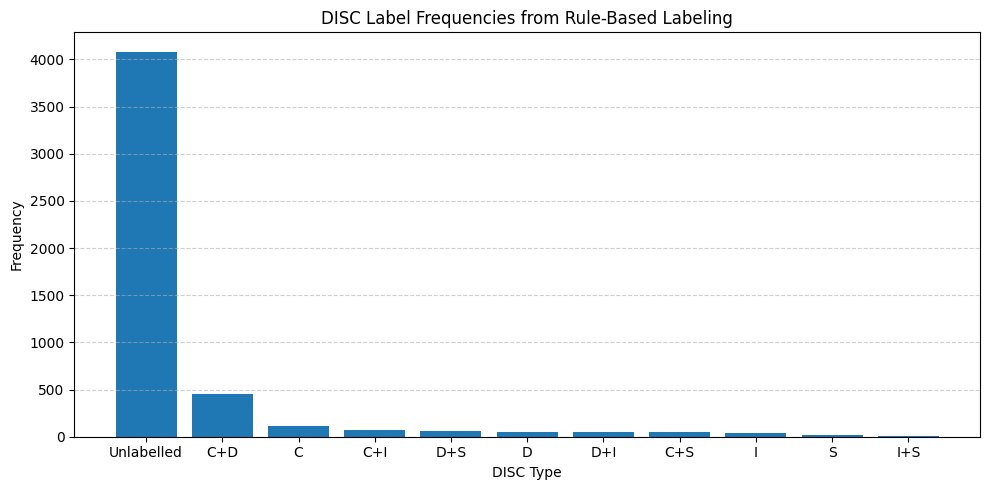

<Figure size 640x480 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt

x_labels = label_count.index.map(lambda x: 'Unlabelled' if isinstance(x, tuple) and len(x) == 0
                                 else '+'.join(x) if isinstance(x, tuple)
                                else str(x))


plt.figure(figsize=(10, 5))
plt.bar(x_labels, label_count.values)
plt.title("DISC Label Frequencies from Rule-Based Labeling")
plt.xlabel("DISC Type")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.savefig('../figures/03_rule_based_disc_label_freq.pnggit add .'
'')

In [12]:
# emails_df_rule_based_none = emails_df_rule_based[emails_df_rule_based['DISC_rule_based'].apply(lambda x: len(x) == 0)]
# print(emails_df_rule_based_none['Entire-Message'])

# emails_df_rule_based_none.to_csv('../data/msg_without_labels.csv', index=False)
# print(emails_df_rule_based_none.value_counts())